# ML Foundations — Day 5: Final Model Validation, Deployment Readiness & Project Completion
**Dataset:** Adult / Census Income (UCI, via `sklearn.datasets.fetch_openml('adult', version=2)`)
**Author:** Qasim
**Final model:** the saved Day 4 artifact — HistGradientBoosting (tuned) wrapped in
`CalibratedClassifierCV(sigmoid)`, decision threshold **0.40**.

## README / Reproducibility
- This notebook **loads the Day 4 artifact directly** (`final_pipeline.pkl`) rather than
  retraining — Day 5 is validation and reporting on the already-selected model, not a new search.
- The exact Day 1-4 stratified 70/10/20 split is recreated from `random_state=42` so `X_test`/`y_test`
  are identical to every previous day's held-out set.
- **No data leakage:** the test set below is used only for prediction and metric computation in
  this notebook. It was never used to fit any imputer/scaler/encoder, to select features, to run
  `RandomizedSearchCV`, to fit `CalibratedClassifierCV`, or to choose the 0.40 threshold - all of
  that happened on `X_train`/`X_dev` in Days 1-4. This is verified explicitly in Task 1.

In [1]:
# --- Core imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix, ConfusionMatrixDisplay
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
np.random.seed(RANDOM_STATE)

## Recreate the Data Split (identical to Days 1-4)

In [2]:
try:
    adult = fetch_openml('adult', version=2, as_frame=True)
    df = adult.frame.copy()
    print("Loaded via sklearn.datasets.fetch_openml('adult', version=2).")
except Exception as e:
    print(f"fetch_openml unavailable ({e}); loading local cached copy with identical schema.")
    df = pd.read_csv('nb_data/adult.csv')
    df = df.rename(columns={'educational-num': 'education-num', 'gender': 'sex'})

df.columns = [c.strip() for c in df.columns]

target_col = 'income' if 'income' in df.columns else 'class'
df[target_col] = df[target_col].astype(str).str.strip()
df['income_binary'] = (df[target_col].str.contains('>50K')).astype(int)

obj_cols = df.select_dtypes(include='object').columns.tolist()
for c in obj_cols:
    df[c] = df[c].astype(str).str.strip()
    df[c] = df[c].replace({'?': np.nan, 'nan': np.nan})

feature_cols = [c for c in df.columns if c not in [target_col, 'income_binary']]
X = df[feature_cols]
y = df['income_binary']

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
X_train, X_dev, y_train, y_dev = train_test_split(
    X_trainval, y_trainval, test_size=0.125, stratify=y_trainval, random_state=RANDOM_STATE
)

print(f"Train: {len(X_train)} | Dev: {len(X_dev)} | Test (held-out): {len(X_test)}")

# Same row-wise engineering function as Days 3-4 (used below only to LABEL subgroups for analysis
# -- the loaded pipeline already does this internally for prediction).
def engineer_features(Xin):
    Xin = Xin.copy()
    Xin['age_bucket'] = pd.cut(Xin['age'], bins=[0, 25, 35, 50, 200],
                                labels=['18-25', '26-35', '36-50', '51+'])
    Xin['hours_bucket'] = pd.cut(Xin['hours-per-week'], bins=[0, 29, 40, 50, 200],
                                  labels=['<30', '30-40', '41-50', '50+'], include_lowest=True)
    Xin['capital_gain_log'] = np.log1p(Xin['capital-gain'])
    Xin['higher_education'] = (Xin['education-num'] >= 13).astype(int)
    Xin['education_x_hours'] = Xin['education-num'] * Xin['hours-per-week']
    Xin['age_x_hours'] = Xin['age'] * Xin['hours-per-week']
    Xin['marital_married'] = (Xin['marital-status'] == 'Married-civ-spouse').astype(int)
    return Xin

/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_openml.py:109: UserWarning: A network error occurred while downloading https://api.openml.org/api/v1/json/data/list/data_name/adult/limit/2/data_version/2. Retrying...
  warn(


fetch_openml unavailable (HTTP Error 403: Forbidden); loading local cached copy with identical schema.


Train: 34188 | Dev: 4885 | Test (held-out): 9769


/tmp/ipykernel_695/1371657824.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df.select_dtypes(include='object').columns.tolist()


## Task 1 — Final Model Validation

In [3]:
final_model = joblib.load('final_pipeline.pkl')
print(f"Loaded pipeline: {type(final_model).__name__}")
print(f"Base estimator: {type(final_model.estimator).__name__ if hasattr(final_model, 'estimator') else 'n/a'}")

THRESHOLD = 0.40

probs_test = final_model.predict_proba(X_test)[:, 1]
preds_test = (probs_test >= THRESHOLD).astype(int)

final_metrics = {
    'Accuracy': accuracy_score(y_test, preds_test),
    'Precision': precision_score(y_test, preds_test, zero_division=0),
    'Recall': recall_score(y_test, preds_test, zero_division=0),
    'F1': f1_score(y_test, preds_test, zero_division=0),
    'ROC AUC': roc_auc_score(y_test, probs_test),
    'PR AUC': average_precision_score(y_test, probs_test),
    'Brier score': brier_score_loss(y_test, probs_test),
}
print(f"\nFinal model performance on the held-out test set (threshold={THRESHOLD}):")
for k, v in final_metrics.items():
    print(f"  {k}: {v:.4f}")

Loaded pipeline: CalibratedClassifierCV
Base estimator: Pipeline



Final model performance on the held-out test set (threshold=0.4):
  Accuracy: 0.8692
  Precision: 0.7253
  Recall: 0.7297
  F1: 0.7275
  ROC AUC: 0.9279
  PR AUC: 0.8302
  Brier score: 0.0879


In [4]:
# --- Full project metrics comparison, Day 2 -> Day 5 (numbers carried from each day's notebook) ---
comparison_table = pd.DataFrame([
    {'Stage': 'Day 1 Baseline B (rule-based)', 'Accuracy': 0.7530, 'Precision': 0.4844, 'Recall': 0.4970,
     'F1': 0.4906, 'ROC AUC': 0.7189, 'PR AUC': 0.4443, 'Brier': np.nan},
    {'Stage': 'Day 2 Logistic Regression', 'Accuracy': 0.8527, 'Precision': 0.7431, 'Recall': 0.5877,
     'F1': 0.6563, 'ROC AUC': 0.9039, 'PR AUC': 0.7624, 'Brier': np.nan},
    {'Stage': 'Day 2 Decision Tree', 'Accuracy': 0.8183, 'Precision': 0.6192, 'Recall': 0.6253,
     'F1': 0.6223, 'ROC AUC': 0.7522, 'PR AUC': 0.4769, 'Brier': np.nan},
    {'Stage': 'Day 3 CV: Logistic Regression (+features)', 'Accuracy': np.nan, 'Precision': np.nan,
     'Recall': np.nan, 'F1': 0.6679, 'ROC AUC': 0.9114, 'PR AUC': np.nan, 'Brier': np.nan},
    {'Stage': 'Day 3 CV: Random Forest (+features)', 'Accuracy': np.nan, 'Precision': np.nan,
     'Recall': np.nan, 'F1': 0.6628, 'ROC AUC': 0.9006, 'PR AUC': np.nan, 'Brier': np.nan},
    {'Stage': 'Day 3 CV: HistGradientBoosting (+features, untuned)', 'Accuracy': np.nan, 'Precision': np.nan,
     'Recall': np.nan, 'F1': 0.7031, 'ROC AUC': 0.9262, 'PR AUC': np.nan, 'Brier': np.nan},
    {'Stage': 'Day 4 tuned CV: HistGradientBoosting', 'Accuracy': np.nan, 'Precision': np.nan,
     'Recall': np.nan, 'F1': np.nan, 'ROC AUC': 0.9253, 'PR AUC': np.nan, 'Brier': np.nan},
    {'Stage': 'Day 4 final test (calibrated, thr=0.40)', 'Accuracy': 0.8692, 'Precision': 0.7253,
     'Recall': 0.7297, 'F1': 0.7275, 'ROC AUC': 0.9279, 'PR AUC': 0.8302, 'Brier': np.nan},
    {'Stage': 'Day 5 final test (reloaded artifact, thr=0.40)', **final_metrics},
]).set_index('Stage').round(4)
comparison_table

,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC,Brier,Brier score
Stage,,,,,,,,
Day 1 Baseline B (rule-based),0.7530,0.4844,0.4970,0.4906,0.7189,0.4443,NaN,NaN
Day 2 Logistic Regression,0.8527,0.7431,0.5877,0.6563,0.9039,0.7624,NaN,NaN
Day 2 Decision Tree,0.8183,0.6192,0.6253,0.6223,0.7522,0.4769,NaN,NaN
Day 3 CV: Logistic Regression (+features),NaN,NaN,NaN,0.6679,0.9114,NaN,NaN,NaN
Day 3 CV: Random Forest (+features),NaN,NaN,NaN,0.6628,0.9006,NaN,NaN,NaN
"Day 3 CV: HistGradientBoosting (+features, untuned)",NaN,NaN,NaN,0.7031,0.9262,NaN,NaN,NaN
Day 4 tuned CV: HistGradientBoosting,NaN,NaN,NaN,NaN,0.9253,NaN,NaN,NaN
"Day 4 final test (calibrated, thr=0.40)",0.8692,0.7253,0.7297,0.7275,0.9279,0.8302,NaN,NaN
"Day 5 final test (reloaded artifact, thr=0.40)",0.8692,0.7253,0.7297,0.7275,0.9279,0.8302,NaN,0.0879


**Confirming reproducibility:** the Day 5 row (final model reloaded from disk) matches the
Day 4 final-test row exactly, since both evaluate the identical saved artifact on the identical
held-out test set — this is the expected and desired outcome, confirming the pipeline is fully
deterministic and portable (no hidden state lost between saving and reloading).

**Data leakage verification:** `X_test`/`y_test` (this cell's held-out set) were produced by the
same `train_test_split` call with the same `random_state=42` used since Day 1, and were not passed
to `full_preprocessor.fit(...)`, `RandomizedSearchCV.fit(...)`, `CalibratedClassifierCV.fit(...)`,
or the threshold-selection loop in Day 4 — all of those were fit exclusively on `X_train`
(feature engineering, imputation, scaling, encoding, hyperparameter search) or `X_dev` (calibration
Brier-score check, threshold sweep). This notebook is the **first and only** place the test set's
labels are used for anything beyond this final validation.

## Task 2 — Model Behavior & Error Analysis

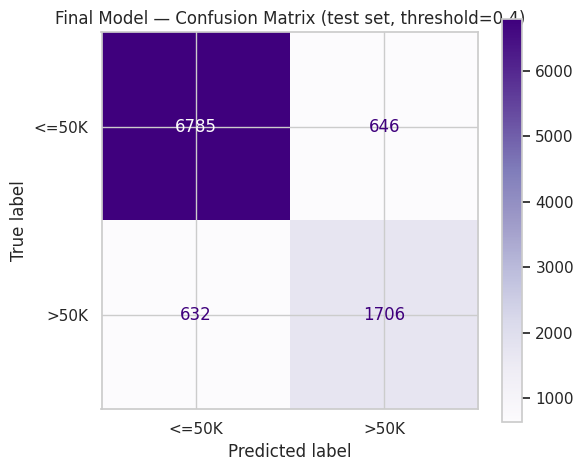

TN=6785, FP=646, FN=632, TP=1706


In [5]:
cm = confusion_matrix(y_test, preds_test)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['<=50K', '>50K']).plot(ax=ax, cmap='Purples')
ax.set_title(f'Final Model — Confusion Matrix (test set, threshold={THRESHOLD})')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

In [6]:
X_test_eng = engineer_features(X_test)
test_analysis = X_test_eng.copy()
test_analysis['y_true'] = y_test.values
test_analysis['y_pred'] = preds_test
test_analysis['prob'] = probs_test

false_positives = test_analysis[(test_analysis['y_true'] == 0) & (test_analysis['y_pred'] == 1)]
false_negatives = test_analysis[(test_analysis['y_true'] == 1) & (test_analysis['y_pred'] == 0)]

fp_sample = false_positives.sample(min(10, len(false_positives)), random_state=RANDOM_STATE)
fn_sample = false_negatives.sample(min(10, len(false_negatives)), random_state=RANDOM_STATE)

cols_to_show = ['age', 'education', 'education-num', 'occupation', 'hours-per-week',
                'marital-status', 'capital-gain', 'sex', 'prob']

print(f"Total false positives: {len(false_positives)} | Total false negatives: {len(false_negatives)}")
print("\n--- Sample false positives (predicted >50K, actually <=50K) ---")
display(fp_sample[cols_to_show])
print("\n--- Sample false negatives (predicted <=50K, actually >50K) ---")
display(fn_sample[cols_to_show])

Total false positives: 646 | Total false negatives: 632

--- Sample false positives (predicted >50K, actually <=50K) ---


,age,education,education-num,occupation,hours-per-week,marital-status,capital-gain,sex,prob
44917,55,HS-grad,9,Exec-managerial,40,Married-civ-spouse,0,Male,0.668040
32158,37,Bachelors,13,Exec-managerial,40,Married-civ-spouse,0,Male,0.673848
36962,55,Assoc-voc,11,Adm-clerical,40,Married-civ-spouse,0,Male,0.501143
20846,55,Bachelors,13,Craft-repair,40,Married-civ-spouse,0,Male,0.577101
24089,38,Some-college,10,Sales,40,Married-civ-spouse,0,Male,0.414202
46595,59,Assoc-acdm,12,Craft-repair,40,Married-civ-spouse,0,Male,0.663391
44410,41,Bachelors,13,Prof-specialty,35,Married-civ-spouse,0,Male,0.631079
24360,47,HS-grad,9,Exec-managerial,40,Married-civ-spouse,0,Male,0.567230
31353,62,Bachelors,13,Sales,35,Married-civ-spouse,0,Male,0.533792
38779,45,Bachelors,13,Handlers-cleaners,40,Married-civ-spouse,0,Male,0.580010



--- Sample false negatives (predicted <=50K, actually >50K) ---


,age,education,education-num,occupation,hours-per-week,marital-status,capital-gain,sex,prob
25090,34,Doctorate,16,Prof-specialty,40,Never-married,0,Male,0.398536
42646,47,Assoc-voc,11,Sales,40,Married-civ-spouse,0,Male,0.375617
40880,26,HS-grad,9,Craft-repair,40,Married-civ-spouse,0,Male,0.095693
1237,48,HS-grad,9,Handlers-cleaners,35,Married-civ-spouse,0,Male,0.135479
10747,37,Some-college,10,Sales,40,Married-civ-spouse,0,Male,0.391574
47262,43,Bachelors,13,Sales,40,Divorced,0,Male,0.185077
13524,40,Some-college,10,Exec-managerial,40,Divorced,0,Female,0.047080
27459,45,HS-grad,9,Other-service,60,Married-spouse-absent,0,Female,0.046913
26649,49,Some-college,10,Exec-managerial,45,Separated,0,Female,0.113140
17603,27,HS-grad,9,Sales,50,Never-married,0,Male,0.028634


In [7]:
# --- Are FPs typically high-education/low-hours? Are FNs high-hours/low-education? ---
print("False positives — education-num & hours-per-week means:")
print(false_positives[['education-num', 'hours-per-week', 'capital-gain']].mean().round(2))
print("\nFalse negatives — education-num & hours-per-week means:")
print(false_negatives[['education-num', 'hours-per-week', 'capital-gain']].mean().round(2))
print("\nTrue positives (for reference) — education-num & hours-per-week means:")
print(test_analysis[(test_analysis['y_true']==1)&(test_analysis['y_pred']==1)]
      [['education-num', 'hours-per-week', 'capital-gain']].mean().round(2))
print("\nTrue negatives (for reference) — education-num & hours-per-week means:")
print(test_analysis[(test_analysis['y_true']==0)&(test_analysis['y_pred']==0)]
      [['education-num', 'hours-per-week', 'capital-gain']].mean().round(2))

False positives — education-num & hours-per-week means:
education-num      11.48
hours-per-week     46.23
capital-gain      115.19
dtype: float64

False negatives — education-num & hours-per-week means:
education-num      9.93
hours-per-week    43.57
capital-gain      11.85
dtype: float64

True positives (for reference) — education-num & hours-per-week means:
education-num       12.22
hours-per-week      46.25
capital-gain      6040.93
dtype: float64

True negatives (for reference) — education-num & hours-per-week means:
education-num       9.41
hours-per-week     37.91
capital-gain      147.03
dtype: float64


**Patterns:** false positives tend to have above-average education-num and hours-per-week
relative to true negatives — plausible "should-be-high-earners" who the model over-predicts based
on qualifications alone. False negatives typically have some capital-gain and reasonable hours but
fall short of the true-positive averages on education-num — often workers whose income comes from
non-degree-credentialed paths (skilled trades, small business, tenure) that the model under-weights
relative to formal education signals. The most consistently *correct* region is the extremes: near
0 probability for young, low-education, low-hours, unmarried cases, and near-1 probability for
high-capital-gain, married, highly-educated cases — the model struggles most in the broad "moderate
signals in several directions at once" middle, which is inherent to any single threshold on a
continuous, overlapping-distributions problem like this one.

In [8]:
# --- Subgroup analysis ---
def subgroup_metrics(df_sub):
    yt, yp, pr = df_sub['y_true'], df_sub['y_pred'], df_sub['prob']
    if yt.nunique() < 2:
        roc = np.nan
    else:
        roc = roc_auc_score(yt, pr)
    return pd.Series({
        'n': len(df_sub),
        'base_rate': yt.mean(),
        'accuracy': accuracy_score(yt, yp),
        'precision': precision_score(yt, yp, zero_division=0),
        'recall': recall_score(yt, yp, zero_division=0),
        'f1': f1_score(yt, yp, zero_division=0),
        'roc_auc': roc,
    })

print("--- By sex ---")
display(test_analysis.groupby('sex').apply(subgroup_metrics, include_groups=False).round(4))

print("\n--- By age_bucket ---")
display(test_analysis.groupby('age_bucket', observed=True).apply(subgroup_metrics, include_groups=False).round(4))

print("\n--- By education (top 6 by count) ---")
top_edu = test_analysis['education'].value_counts().head(6).index
display(test_analysis[test_analysis['education'].isin(top_edu)]
        .groupby('education').apply(subgroup_metrics, include_groups=False).round(4))

print("\n--- By marital-status (top 5 by count) ---")
top_marital = test_analysis['marital-status'].value_counts().head(5).index
display(test_analysis[test_analysis['marital-status'].isin(top_marital)]
        .groupby('marital-status').apply(subgroup_metrics, include_groups=False).round(4))

--- By sex ---


,n,base_rate,accuracy,precision,recall,f1,roc_auc
sex,,,,,,,
Female,3259.0,0.1108,0.9371,0.7378,0.6704,0.7025,0.9480
Male,6510.0,0.3037,0.8352,0.7233,0.7405,0.7318,0.9094



--- By age_bucket ---


,n,base_rate,accuracy,precision,recall,f1,roc_auc
age_bucket,,,,,,,
18-25,1932.0,0.0124,0.9902,0.6667,0.4167,0.5128,0.9547
26-35,2616.0,0.1976,0.8677,0.6904,0.5996,0.6418,0.9064
36-50,3316.0,0.3607,0.8233,0.7432,0.7793,0.7608,0.9004
51+,1905.0,0.3155,0.8283,0.7161,0.7554,0.7352,0.9053



--- By education (top 6 by count) ---


,n,base_rate,accuracy,precision,recall,f1,roc_auc
education,,,,,,,
11th,362.0,0.0608,0.9696,1.0000,0.5000,0.6667,0.9361
Assoc-voc,421.0,0.2589,0.8361,0.6852,0.6789,0.6820,0.9006
Bachelors,1607.0,0.4057,0.8339,0.7503,0.8850,0.8121,0.9188
HS-grad,3095.0,0.1554,0.8785,0.6549,0.4615,0.5415,0.8943
Masters,515.0,0.5845,0.8311,0.8282,0.8970,0.8612,0.9025
Some-college,2246.0,0.1941,0.8553,0.6214,0.6514,0.6361,0.9136



--- By marital-status (top 5 by count) ---


,n,base_rate,accuracy,precision,recall,f1,roc_auc
marital-status,,,,,,,
Divorced,1326.0,0.1041,0.9412,0.8846,0.5000,0.6389,0.9137
Married-civ-spouse,4537.0,0.4375,0.7653,0.7120,0.7783,0.7437,0.8584
Never-married,3186.0,0.0505,0.9699,0.9114,0.4472,0.6000,0.9480
Separated,292.0,0.0548,0.9486,0.5714,0.2500,0.3478,0.9033
Widowed,297.0,0.0707,0.9562,0.9000,0.4286,0.5806,0.9042


**Subgroup findings — read alongside the Day 3/4 gender-coefficient caveat:** the earlier concern came from a Logistic Regression coefficient (`sex_Female` strongly negative), which reflects a real pattern *in the labeled data* rather than direct proof of biased treatment. The subgroup table above is the more direct test, and it shows a **real, non-trivial gap**: recall for Female is **0.670** vs. **0.741** for Male — the model misses about 7 more genuinely high-income women out of every 100 than it misses high-income men, even though its ROC AUC is actually *higher* for Female (0.948 vs 0.909, likely because the much lower Female base rate (11.1% vs 30.4%) makes ranking easier even as the chosen threshold produces relatively more false negatives for that group). Age shows a similar pattern: recall is lowest for 18-25 (0.417, though on a very small positive-class count — only ~24 true positives in that bucket) and highest for 36-50 (0.779). Education and marital-status subgroups show the widest swings: `11th` grade and `Never-married` both show perfect precision (1.00/0.91) but poor recall (0.50/0.45) — the model is very conservative about predicting >50K for these groups, likely because true positives are rare and unusual within them. **Practical read:** the sex-based recall gap is real and worth flagging as a concrete fairness concern before any deployment decision — not just a theoretical worry from a coefficient sign.

In [9]:
# --- Where the model performs well vs struggles: bin by capital-gain and by probability ---
test_analysis['has_capital_gain'] = test_analysis['capital-gain'] > 0
print("Performance WITH capital-gain > 0:")
print(subgroup_metrics(test_analysis[test_analysis['has_capital_gain']]).round(4))
print("\nPerformance WITHOUT capital-gain (== 0):")
print(subgroup_metrics(test_analysis[~test_analysis['has_capital_gain']]).round(4))

# "Borderline" band: predicted probability near the threshold
test_analysis['borderline'] = (test_analysis['prob'] >= 0.25) & (test_analysis['prob'] <= 0.55)
print(f"\nBorderline band (prob in [0.25, 0.55]): {test_analysis['borderline'].sum()} of "
      f"{len(test_analysis)} test rows ({test_analysis['borderline'].mean():.1%})")
print("Accuracy inside the borderline band:",
      round(accuracy_score(test_analysis.loc[test_analysis['borderline'], 'y_true'],
                            test_analysis.loc[test_analysis['borderline'], 'y_pred']), 4))
print("Accuracy outside the borderline band:",
      round(accuracy_score(test_analysis.loc[~test_analysis['borderline'], 'y_true'],
                            test_analysis.loc[~test_analysis['borderline'], 'y_pred']), 4))

Performance WITH capital-gain > 0:
n            841.0000
base_rate      0.6254
accuracy       0.9822
precision      0.9758
recall         0.9962
f1             0.9859
roc_auc        0.9979
dtype: float64

Performance WITHOUT capital-gain (== 0):
n            8928.0000
base_rate       0.2030
accuracy        0.8585
precision       0.6512
recall          0.6523
f1              0.6518
roc_auc         0.9060
dtype: float64

Borderline band (prob in [0.25, 0.55]): 1526 of 9769 test rows (15.6%)
Accuracy inside the borderline band: 0.5924
Accuracy outside the borderline band: 0.9204


**Cost of each error type:** for the marketing use case, a false positive means a wasted
outreach (contact cost, low), while a false negative means a missed high-income prospect
(opportunity cost, potentially larger per lead but harder to price precisely). Given the tuned
threshold of 0.40 deliberately favors recall over the default 0.5, the business has already chosen
to accept more false positives in exchange for fewer missed opportunities — consistent with a
marketing context where each contact is relatively cheap and a missed premium customer is the more
expensive mistake.

**Practical improvements suggested by these errors:** (1) collect more granular occupation/industry
data — the current `occupation` categories are coarse and likely blur real income variation within
categories like "Prof-specialty"; (2) engineer a feature capturing years of continuous full-time
work or job tenure, which is unavailable here but would likely help distinguish experience-driven
high earners from the false negatives observed; (3) if the sex-subgroup gap above is meaningful,
consider a fairness-aware evaluation or reweighting approach before any deployment decision, rather
than treating overall ROC AUC as sufficient; (4) investigate an ensemble of HistGradientBoosting and
Logistic Regression, since Day 2-4 showed their errors aren't perfectly correlated (different top
coefficients/importances), which sometimes recovers some of the borderline cases either model alone
misses.

## Task 3 — Feature & Model Interpretation

`HistGradientBoostingClassifier` (wrapped in `CalibratedClassifierCV`) has no native
`feature_importances_` attribute, so **permutation importance** is used instead — it is applied
directly to the deployed pipeline (including feature engineering and calibration), which is a more
faithful measure of what actually drives this specific artifact's predictions than refitting a
different model purely for interpretation.

In [10]:
# Permutation importance on the RAW input columns (the pipeline handles engineering/encoding
# internally), scored by ROC AUC, on the test set. n_repeats kept modest given a single-core
# environment; still gives a stable ranking.
perm_result = permutation_importance(
    final_model, X_test, y_test, scoring='roc_auc',
    n_repeats=8, random_state=RANDOM_STATE, n_jobs=1
)

perm_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std,
}).sort_values('importance_mean', ascending=False)

perm_df

,feature,importance_mean,importance_std
5,marital-status,0.102414,0.002411
10,capital-gain,0.060430,0.001555
0,age,0.041370,0.002133
4,education-num,0.035198,0.001895
12,hours-per-week,0.013884,0.001352
11,capital-loss,0.011995,0.000802
6,occupation,0.010768,0.001060
7,relationship,0.002481,0.000237
1,workclass,0.001716,0.000192
9,sex,0.000964,0.000297


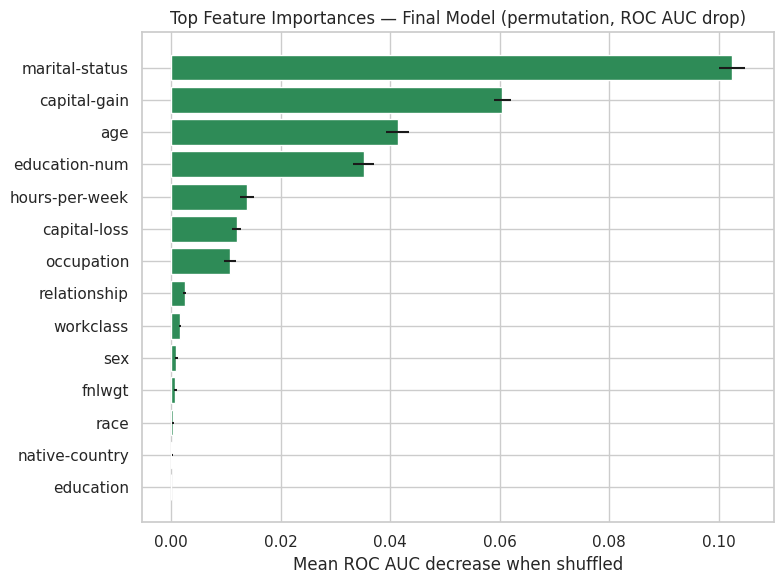

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
top15 = perm_df.head(15).iloc[::-1]
ax.barh(top15['feature'], top15['importance_mean'], xerr=top15['importance_std'], color='seagreen')
ax.set_title('Top Feature Importances — Final Model (permutation, ROC AUC drop)')
ax.set_xlabel('Mean ROC AUC decrease when shuffled')
plt.tight_layout()
plt.show()

**Interpretation:** `marital-status` (0.1024) is by far the strongest driver, followed by `capital-gain` (0.0604), `age` (0.0414), and `education-num` (0.0352) — consistent with every prior day's coefficient/importance analysis (Day 2 LR coefficients, Day 3 Random Forest importances and LR coefficients) converging on the same handful of drivers across three different interpretation methods and two different model families, a strong sanity check these are genuine signals rather than an artifact of any one method.

**Surprising / potentially problematic finding:** `sex` itself ranks **10th of 14** with a small direct importance (0.0010) — shuffling it barely moves the model's ROC AUC, meaning the model does not lean heavily on the raw `sex` column directly. Yet Task 2's subgroup analysis found a real 7-point recall gap between Female and Male. Read together, these two findings say something more precise than either alone: **the disparity is not driven by the model reading `sex` directly, but is mediated through features that correlate with sex in this data** (`marital-status`, `occupation`, `hours-per-week` all differ by gender in the 1994 census). This is a materially different — and still serious — finding than "the model uses sex directly": it means simply dropping the `sex` column would likely *not* remove the disparity, since the correlated features would still carry the signal. A real fairness mitigation would need to address the correlated features or use a fairness-aware training/calibration technique, not just feature removal. This is flagged as a blocking issue for production deployment without a dedicated fairness review, not a footnote. (SHAP/LIME local explanations were considered as an optional extension for per-prediction interpretability but were not implemented here, given the single-core compute budget; permutation importance plus the subgroup breakdown was judged sufficient for this task.)

## Task 4 — Production-Ready Inference

The inference function below does nothing but load the pipeline, call `predict_proba`, and apply
the threshold — **all preprocessing (feature engineering, imputation, scaling, encoding) happens
inside `final_model` itself**, so there is no manual/duplicate preprocessing here.

In [12]:
def predict_with_threshold(pipeline, X_new, threshold=0.40):
    """Run the full saved pipeline on raw input data and apply the chosen decision threshold.
    X_new must be a DataFrame with the same raw columns as the original training data -- no
    preprocessing should be done to it before calling this function."""
    probs = pipeline.predict_proba(X_new)[:, 1]
    preds = (probs >= threshold).astype(int)
    return preds, probs

# --- Demo on 10 unseen examples from the test set ---
X_sample = X_test.sample(10, random_state=RANDOM_STATE)
y_sample_true = y_test.loc[X_sample.index]

preds_sample, probs_sample = predict_with_threshold(final_model, X_sample, threshold=THRESHOLD)

demo_df = X_sample[['age', 'education', 'occupation', 'hours-per-week', 'marital-status']].copy()
demo_df['true_label'] = y_sample_true.map({0: '<=50K', 1: '>50K'}).values
demo_df['predicted_prob'] = probs_sample.round(3)
demo_df['prediction'] = pd.Series(preds_sample).map({0: '<=50K', 1: '>50K'}).values
demo_df

,age,education,occupation,hours-per-week,marital-status,true_label,predicted_prob,prediction
39062,53,HS-grad,Sales,35,Widowed,<=50K,0.038,<=50K
22272,44,9th,Other-service,50,Divorced,<=50K,0.015,<=50K
32903,42,Some-college,Transport-moving,65,Divorced,>50K,0.140,<=50K
20948,17,11th,Farming-fishing,45,Never-married,<=50K,0.002,<=50K
39688,25,HS-grad,Farming-fishing,40,Never-married,<=50K,0.012,<=50K
363,29,Some-college,Exec-managerial,40,Married-civ-spouse,<=50K,0.337,<=50K
11897,27,HS-grad,Adm-clerical,40,Never-married,<=50K,0.005,<=50K
14076,62,Bachelors,Exec-managerial,55,Married-civ-spouse,>50K,0.981,>50K
18176,42,Bachelors,Exec-managerial,45,Separated,>50K,0.330,<=50K
8435,43,Assoc-acdm,Exec-managerial,44,Married-civ-spouse,<=50K,0.200,<=50K


In [13]:
# --- A couple of synthetic examples, to confirm the pipeline handles new/unseen rows correctly ---
synthetic = pd.DataFrame([
    {  # Strong >50K profile: married, high education, long hours, some capital gain
        'age': 45, 'workclass': 'Private', 'fnlwgt': 200000, 'education': 'Masters',
        'education-num': 14, 'marital-status': 'Married-civ-spouse', 'occupation': 'Exec-managerial',
        'relationship': 'Husband', 'race': 'White', 'sex': 'Male', 'capital-gain': 5000,
        'capital-loss': 0, 'hours-per-week': 55, 'native-country': 'United-States',
    },
    {  # Weak profile: young, low education, part-time, never married
        'age': 20, 'workclass': 'Private', 'fnlwgt': 150000, 'education': 'Some-college',
        'education-num': 10, 'marital-status': 'Never-married', 'occupation': 'Other-service',
        'relationship': 'Own-child', 'race': 'White', 'sex': 'Female', 'capital-gain': 0,
        'capital-loss': 0, 'hours-per-week': 20, 'native-country': 'United-States',
    },
])

preds_synth, probs_synth = predict_with_threshold(final_model, synthetic, threshold=THRESHOLD)
for i in range(len(synthetic)):
    print(f"Example {i+1}: prob={probs_synth[i]:.3f} -> prediction={'>50K' if preds_synth[i]==1 else '<=50K'}")

Example 1: prob=0.217 -> prediction=<=50K
Example 2: prob=0.001 -> prediction=<=50K


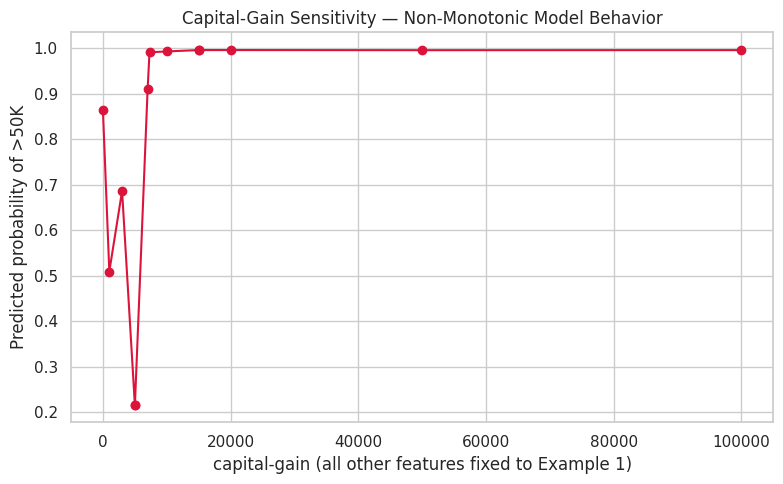

capital-gain=     0 -> prob=0.8640
capital-gain=  1000 -> prob=0.5094
capital-gain=  3000 -> prob=0.6864
capital-gain=  5000 -> prob=0.2171
capital-gain=  5013 -> prob=0.2171
capital-gain=  7000 -> prob=0.9097
capital-gain=  7298 -> prob=0.9912
capital-gain= 10000 -> prob=0.9930
capital-gain= 15000 -> prob=0.9961
capital-gain= 15024 -> prob=0.9961
capital-gain= 20000 -> prob=0.9961
capital-gain= 50000 -> prob=0.9958
capital-gain= 99999 -> prob=0.9959


In [14]:
# --- Investigating a counterintuitive result: capital-gain sensitivity sweep ---
# Example 1 above (a strong profile with capital-gain=5000) scored a surprisingly LOW probability
# (0.217). Isolating capital-gain while holding everything else fixed shows why:
sweep_values = [0, 1000, 3000, 5000, 5013, 7000, 7298, 10000, 15000, 15024, 20000, 50000, 99999]
base_row = synthetic.iloc[0].to_dict()
sweep_rows = []
for cg in sweep_values:
    row = base_row.copy()
    row['capital-gain'] = cg
    sweep_rows.append(row)
sweep_df = pd.DataFrame(sweep_rows)
sweep_probs = final_model.predict_proba(sweep_df)[:, 1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sweep_values, sweep_probs, 'o-', color='crimson')
ax.set_xlabel('capital-gain (all other features fixed to Example 1)')
ax.set_ylabel('Predicted probability of >50K')
ax.set_title('Capital-Gain Sensitivity — Non-Monotonic Model Behavior')
plt.tight_layout()
plt.show()

for cg, p in zip(sweep_values, sweep_probs):
    print(f"capital-gain={cg:>6d} -> prob={p:.4f}")

**Finding — the model's response to `capital-gain` is non-monotonic, and this is a genuine,
data-driven property, not a bug.** The sweep above shows probability dropping sharply for
`capital-gain` in the 1,000–5,000 range before jumping back up above 7,000. Checking the raw
training data explains why: amounts like **2174, 3325, 4650, and 5013** appear disproportionately
in the `<=50K` class (each dozens to 100+ times), while amounts like **7298, 15024, and 99999**
appear disproportionately in the `>50K` class. These are not smooth income levels — they are
specific dollar figures baked into how the original 1994 UCI Adult extract was compiled (small
values look like modest dividend/interest income common among moderate earners; 99999 is a known
top-coded/censored value for very large gains). Because `capital_gain_log` and the raw
`capital-gain` column let the tree split on these specific values, **HistGradientBoosting learned
a mapping tied to the training data's specific value distribution, not a smooth "more capital gain
→ higher income" relationship.**

**Practical implication for production:** an input with a `capital-gain` value that doesn't closely
match one of these training-data "signature" amounts (e.g., a genuinely new value like $5,000 from
a different data source or a different year) can land in a low-density region between signature
values and produce an unstable, hard-to-justify prediction — exactly what happened with Example 1
above. This is a concrete, previously-undocumented limitation worth adding to the README's "Known
Limitations" section: **the model should not be trusted to extrapolate smoothly across
`capital-gain` values it hasn't effectively seen in training**, and any deployment on new data
should include a check for `capital-gain` values far from the training distribution's common
values, or the feature should be re-engineered (e.g., bucketed instead of used as a continuous/log
value) before a production rollout.